In [112]:
import pandas as pd
predictions = pd.read_csv('extra/results/predictions_bs_bf.csv')
predictions.head()

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,eid
0,ENSG00000132470,1,0.087409,0,0,0.137287,0,0,E116
1,ENSG00000197446,0,0.020184,0,0,0.028083,0,0,E116
2,ENSG00000136110,0,0.069456,0,0,0.088738,0,0,E116
3,ENSG00000105576,1,0.979691,1,1,0.834360,1,0,E116
4,ENSG00000136872,0,0.042485,0,0,0.048272,0,0,E116


In [113]:
eid = 'E003'
predictions_E003 = predictions[predictions['eid'] == eid]   
meta_data_E003 = pd.read_csv(f'extra/datasets/processed/v2/meta_datasets/meta_data_{eid}.csv')
filter_result = predictions_E003[(predictions_E003['bf_label_label'] != predictions_E003['bf_label_pred']) & (predictions_E003['bs_label_label'] == predictions_E003['bs_label_pred'])]
# filter_result

In [114]:
data_merged = pd.merge(filter_result, meta_data_E003[['gene_id','chrom','start','end','strand','gene_name', 'expression','bulk_exp','bs','bf']], on='gene_id', how='inner')
data_merged

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,eid,chrom,start,end,strand,gene_name,expression,bulk_exp,bs,bf
0,ENSG00000172465,1,0.635196,1,0,0.539351,1,0,E003,chrX,102883901,102883902,+,TCEAL1,0.418398,2.972,25.934493,0.020434
1,ENSG00000119408,1,0.650077,1,0,0.616437,1,0,E003,chr9,127020194,127020195,+,NEK6,2.026706,6.732,63.501420,0.033825
2,ENSG00000119401,1,0.719862,1,0,0.787348,1,0,E003,chr9,119449582,119449583,+,TRIM32,2.721068,5.900,77.929227,0.035350
3,ENSG00000108947,1,0.569550,1,1,0.368054,0,0,E003,chr17,7608518,7608519,+,EFNB3,3.370920,16.716,87.280259,0.044910
4,ENSG00000198157,0,0.463972,0,1,0.168839,0,0,E003,chrX,80457412,80457413,-,HMGN5,7.219585,44.392,24.636776,0.298463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,ENSG00000171456,1,0.661815,1,1,0.363049,0,3,E003,chr20,30946145,30946146,+,ASXL1,6.035608,4.451,35.214564,0.197792
1103,ENSG00000163935,1,0.684886,1,0,0.615124,1,3,E003,chr3,53080089,53080090,-,SFMBT1,1.207715,4.801,40.246968,0.034090
1104,ENSG00000127561,1,0.522078,1,1,0.422468,0,3,E003,chr16,2039969,2039970,+,SYNGR3,3.169139,15.300,57.558080,0.050587
1105,ENSG00000179242,0,0.177478,0,1,0.107391,0,3,E003,chr20,60074475,60074476,+,CDH4,0.896142,7.208,15.278155,0.059036


In [115]:
import os
data_dir = 'extra/datasets/burst/raw_data/H1/'
data_df = pd.read_csv(os.path.join(data_dir ,"H1_RNA.csv"), sep=',',index_col=0).T
# data_df

3.169139465875371


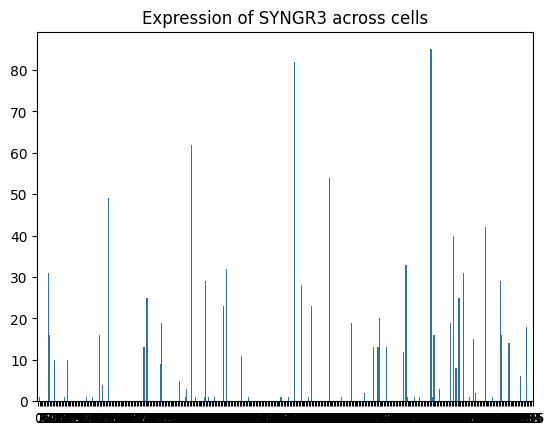

In [116]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
target_genes = 'SYNGR3'
sns.barplot(x=range(len(data_df[[target_genes]])), y=data_df[[target_genes]].values.flatten())
print(np.mean(data_df[[target_genes]].values.flatten()))
plt.title(f'Expression of {target_genes} across cells')
plt.show()  

3.169139465875371


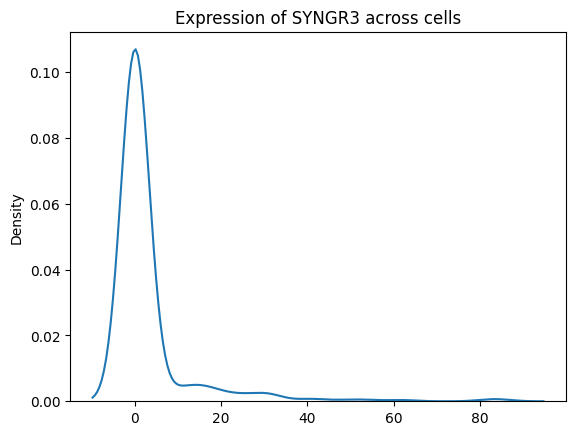

In [117]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
target_genes = 'SYNGR3'
sns.kdeplot(data_df[[target_genes]].values.flatten())
print(np.mean(data_df[[target_genes]].values.flatten()))
plt.title(f'Expression of {target_genes} across cells')
plt.show()  

In [118]:
data_merged[data_merged['bs_label_label']==1]

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,eid,chrom,start,end,strand,gene_name,expression,bulk_exp,bs,bf
0,ENSG00000172465,1,0.635196,1,0,0.539351,1,0,E003,chrX,102883901,102883902,+,TCEAL1,0.418398,2.972,25.934493,0.020434
1,ENSG00000119408,1,0.650077,1,0,0.616437,1,0,E003,chr9,127020194,127020195,+,NEK6,2.026706,6.732,63.501420,0.033825
2,ENSG00000119401,1,0.719862,1,0,0.787348,1,0,E003,chr9,119449582,119449583,+,TRIM32,2.721068,5.900,77.929227,0.035350
3,ENSG00000108947,1,0.569550,1,1,0.368054,0,0,E003,chr17,7608518,7608519,+,EFNB3,3.370920,16.716,87.280259,0.044910
5,ENSG00000100027,1,0.749385,1,0,0.819328,1,0,E003,chr22,22090083,22090084,-,YPEL1,1.451039,4.973,44.812062,0.030220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1101,ENSG00000172071,1,0.570123,1,1,0.420966,0,3,E003,chr2,88924447,88924448,-,EIF2AK3,0.913947,13.528,29.260864,0.042440
1102,ENSG00000171456,1,0.661815,1,1,0.363049,0,3,E003,chr20,30946145,30946146,+,ASXL1,6.035608,4.451,35.214564,0.197792
1103,ENSG00000163935,1,0.684886,1,0,0.615124,1,3,E003,chr3,53080089,53080090,-,SFMBT1,1.207715,4.801,40.246968,0.034090
1104,ENSG00000127561,1,0.522078,1,1,0.422468,0,3,E003,chr16,2039969,2039970,+,SYNGR3,3.169139,15.300,57.558080,0.050587


3.7270029673590503


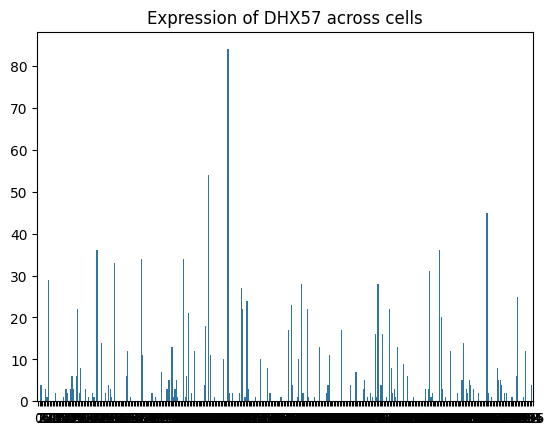

In [119]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
target_genes = 'DHX57'
sns.barplot(x=range(len(data_df[[target_genes]])), y=data_df[[target_genes]].values.flatten())
print(np.mean(data_df[[target_genes]].values.flatten()))
plt.title(f'Expression of {target_genes} across cells')
plt.show()  

3.7270029673590503


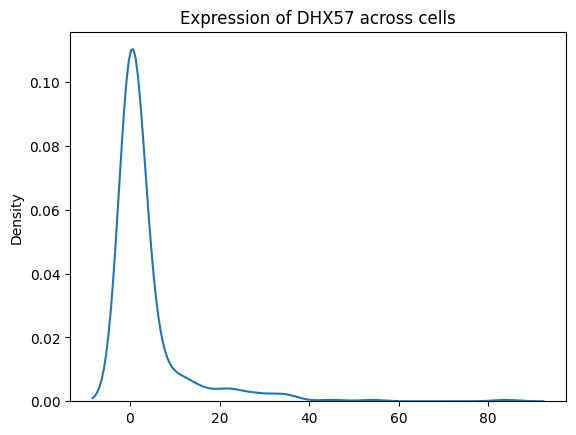

In [120]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
target_genes = 'DHX57'
sns.kdeplot(data_df[[target_genes]].values.flatten())
print(np.mean(data_df[[target_genes]].values.flatten()))
plt.title(f'Expression of {target_genes} across cells')
plt.show()  

## High BF 预测正确， High BS 预测错误

In [121]:
eid = 'E003'
predictions_E003 = predictions[predictions['eid'] == eid]   
meta_data_E003 = pd.read_csv(f'extra/datasets/processed/v2/meta_datasets/meta_data_{eid}.csv')
filter_result = predictions_E003[(predictions_E003['bf_label_label'] == predictions_E003['bf_label_pred']) & (predictions_E003['bs_label_label'] != predictions_E003['bs_label_pred'])]
data_merged = pd.merge(filter_result, meta_data_E003[['gene_id','chrom','start','end','strand','gene_name', 'expression','bulk_exp','bs','bf']], on='gene_id', how='inner')
data_merged[(data_merged['bf_label_label']==1) & (data_merged['bs_label_label']==1)]

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,eid,chrom,start,end,strand,gene_name,expression,bulk_exp,bs,bf
442,ENSG00000161249,1,0.476820,0,1,0.500345,1,0,E003,chr19,35992813,35992814,-,DMKN,21.192878,30.001,71.488895,0.277795
612,ENSG00000102225,1,0.451554,0,1,0.524650,1,0,E003,chrX,47082415,47082416,+,CDK16,7.000000,22.347,42.959144,0.173396
614,ENSG00000187764,1,0.460992,0,1,0.514006,1,0,E003,chr9,92094805,92094806,-,SEMA4D,1.439169,14.103,31.891114,0.050461
758,ENSG00000165588,1,0.451443,0,1,0.564276,1,1,E003,chr14,57277197,57277198,-,OTX2,16.854599,6.402,69.184413,0.223942
977,ENSG00000204580,1,0.474852,0,1,0.583382,1,1,E003,chr6,30856463,30856464,+,DDR1,4.454006,42.967,26.462183,0.191524
1530,ENSG00000140553,1,0.319068,0,1,0.610020,1,2,E003,chr15,91473408,91473409,+,UNC45A,4.958457,9.563,44.448986,0.119768
1531,ENSG00000089053,1,0.468478,0,1,0.921471,1,2,E003,chr12,121792012,121792013,-,ANAPC5,33.462908,13.839,73.187448,0.440653
1539,ENSG00000174498,1,0.493273,0,1,0.894018,1,2,E003,chr15,65670340,65670341,-,IGDCC3,13.667656,50.322,41.285526,0.370912
1575,ENSG00000173457,1,0.493503,0,1,0.899440,1,2,E003,chr11,64014415,64014416,-,PPP1R14B,29.454006,113.367,27.826191,1.015783
1855,ENSG00000164828,1,0.470046,0,1,0.542049,1,2,E003,chr7,872111,872112,+,SUN1,5.350148,27.810,26.400480,0.190207


4.958456973293768


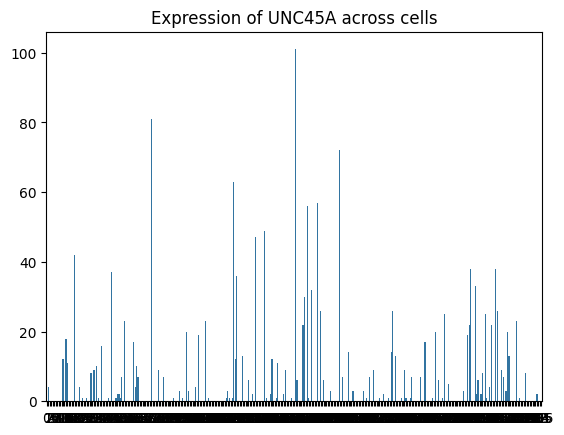

In [122]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
target_genes = 'UNC45A'
sns.barplot(x=range(len(data_df[[target_genes]])), y=data_df[[target_genes]].values.flatten())
print(np.mean(data_df[[target_genes]].values.flatten()))
plt.title(f'Expression of {target_genes} across cells')
plt.show()  

4.958456973293768


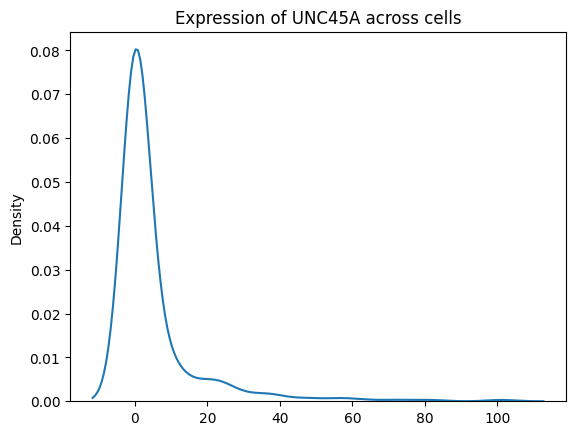

In [123]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
target_genes = 'UNC45A'
sns.kdeplot(data_df[[target_genes]].values.flatten())
print(np.mean(data_df[[target_genes]].values.flatten()))
plt.title(f'Expression of {target_genes} across cells')
plt.show()  

In [124]:
kinetics_origin = pd.read_csv('extra/datasets/burst/processed_v2/H1_statistic_gene_transcript_region_delay_1.0.csv')
kinetics_origin[kinetics_origin['gene_name']==target_genes]

,expression,bs,bf,k_on,k_off,k_syn,gene_name,gene_id
17018,4.958457,45.651067,0.111173,0.111173,3.13338,143.042158,UNC45A,ENSG00000140553


error_group  BF correct / BS correct  BF correct / BS wrong  \
cell_type                                                     
H1                              9870                   2853   
GM12878                        11552                   1783   
HepG2                           8489                   3246   

error_group  BF wrong / BS correct  BF wrong / BS wrong  
cell_type                                                
H1                            1107                  590  
GM12878                       2148                  382  
HepG2                         1992                  580  


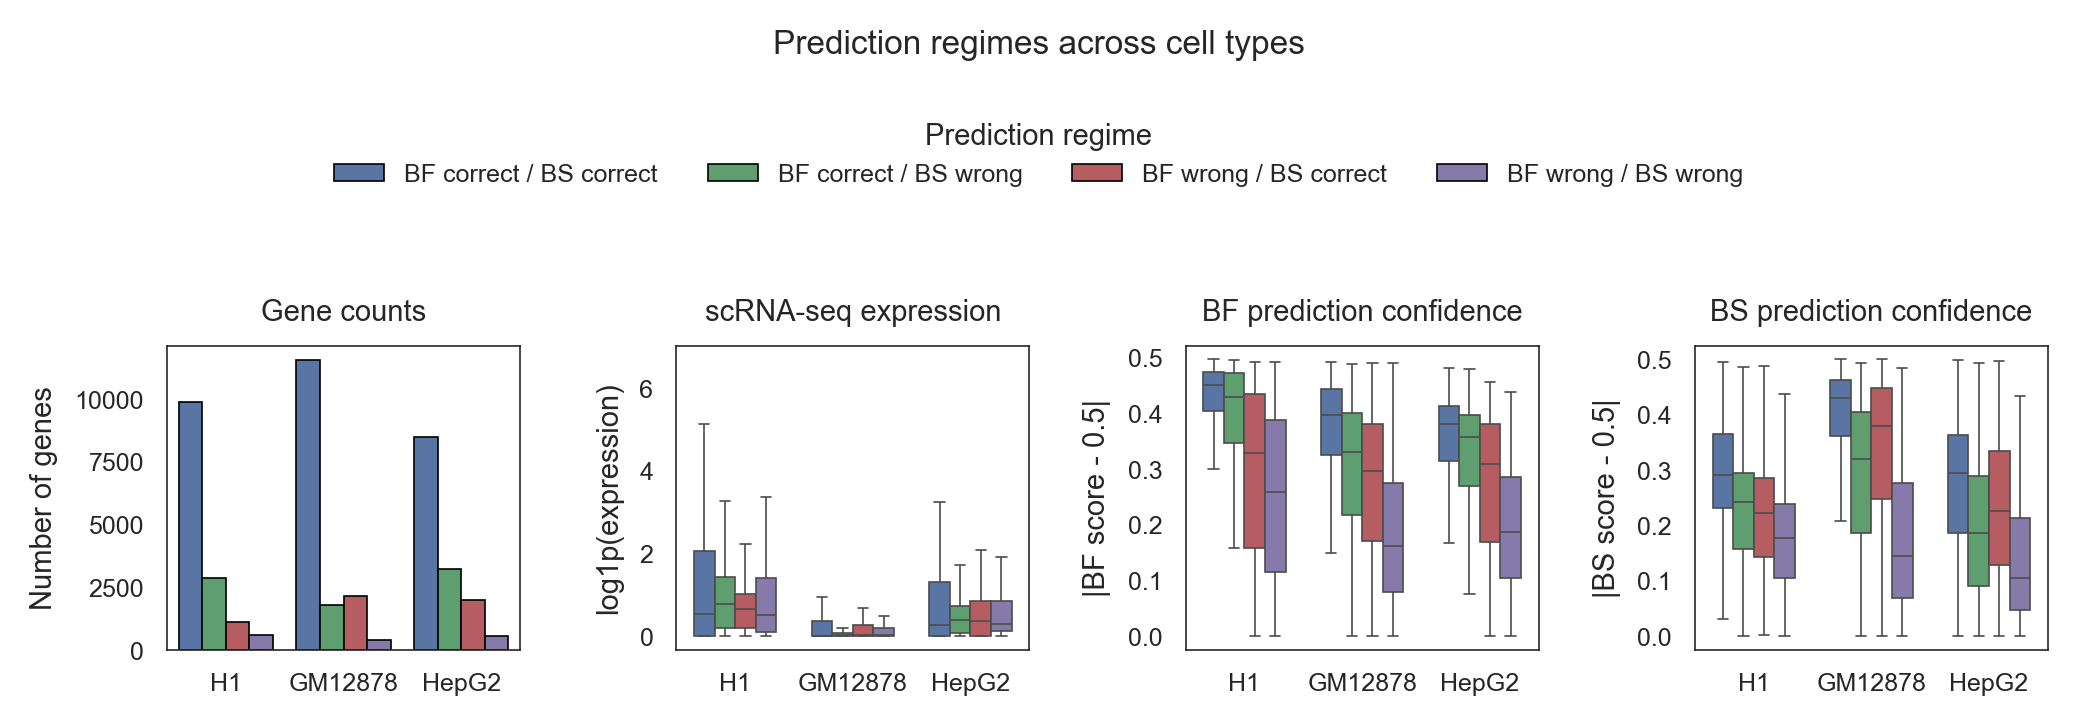

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# 1. Basic settings
# =========================

EIDS = ["E003", "E116", "E118"]

eid_to_celltype = {
    "E003": "H1",
    "E116": "GM12878",
    "E118": "HepG2",
}

celltype_order = ["H1", "GM12878", "HepG2"]

group_order = [
    "BF correct / BS correct",
    "BF correct / BS wrong",
    "BF wrong / BS correct",
    "BF wrong / BS wrong",
]

palette = {
    "BF correct / BS correct": "#4C72B0",
    "BF correct / BS wrong": "#55A868",
    "BF wrong / BS correct": "#C44E52",
    "BF wrong / BS wrong": "#8172B2",
}


# =========================
# 2. Merge predictions and metadata
# =========================

merged_list = []

for eid in EIDS:
    pred_sub = predictions[predictions["eid"] == eid].copy()

    meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}.csv"
    meta_sub = pd.read_csv(meta_path)

    keep_cols = [
        "gene_id",
        "chrom",
        "start",
        "end",
        "strand",
        "gene_name",
        "expression",
        "bulk_exp",
        "bs",
        "bf",
    ]

    meta_sub = meta_sub[[col for col in keep_cols if col in meta_sub.columns]].copy()

    data_sub = pd.merge(
        pred_sub,
        meta_sub,
        on="gene_id",
        how="inner",
    )

    data_sub["eid"] = eid
    data_sub["cell_type"] = eid_to_celltype[eid]

    merged_list.append(data_sub)

df = pd.concat(merged_list, axis=0, ignore_index=True)


# =========================
# 3. Define BF / BS correctness regimes
# =========================

df["bf_correct"] = df["bf_label_label"] == df["bf_label_pred"]
df["bs_correct"] = df["bs_label_label"] == df["bs_label_pred"]


def assign_error_group(row):
    if row["bf_correct"] and row["bs_correct"]:
        return "BF correct / BS correct"
    elif row["bf_correct"] and (not row["bs_correct"]):
        return "BF correct / BS wrong"
    elif (not row["bf_correct"]) and row["bs_correct"]:
        return "BF wrong / BS correct"
    else:
        return "BF wrong / BS wrong"


df["error_group"] = df.apply(assign_error_group, axis=1)

df["cell_type"] = pd.Categorical(
    df["cell_type"],
    categories=celltype_order,
    ordered=True,
)

df["error_group"] = pd.Categorical(
    df["error_group"],
    categories=group_order,
    ordered=True,
)


# =========================
# 4. Add plotting variables
# =========================

df["log_expression"] = np.log1p(df["expression"])
df["log_bulk_exp"] = np.log1p(df["bulk_exp"])

df["bf_confidence"] = np.abs(df["bf_label_score"] - 0.5)
df["bs_confidence"] = np.abs(df["bs_label_score"] - 0.5)


# =========================
# 5. Summary table
# =========================

count_summary = (
    df.groupby(["cell_type", "error_group"], observed=False)
    .size()
    .reset_index(name="n_genes")
)

print(count_summary.pivot(
    index="cell_type",
    columns="error_group",
    values="n_genes"
).loc[celltype_order, group_order])


# =========================
# 6. Plot
# =========================

sns.set_theme(style="white", font="Arial")

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18 / 2.54, 5 / 2.54),
    dpi=300,
)

# ---- Panel 1: gene count ----
sns.barplot(
    data=count_summary,
    x="cell_type",
    y="n_genes",
    hue="error_group",
    order=celltype_order,
    hue_order=group_order,
    palette=palette,
    ax=axes[0],
    linewidth=0.4,
    edgecolor="black",
)

axes[0].set_title("Gene counts", fontsize=7)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of genes", fontsize=7)


# ---- Panel 2: scRNA-seq expression ----
sns.boxplot(
    data=df,
    x="cell_type",
    y="log_expression",
    hue="error_group",
    order=celltype_order,
    hue_order=group_order,
    palette=palette,
    ax=axes[1],
    fliersize=0,
    linewidth=0.4,
    width=0.7,
)

axes[1].set_title("scRNA-seq expression", fontsize=7)
axes[1].set_xlabel("")
axes[1].set_ylabel("log1p(expression)", fontsize=7)


# ---- Panel 3: BF confidence ----
sns.boxplot(
    data=df,
    x="cell_type",
    y="bf_confidence",
    hue="error_group",
    order=celltype_order,
    hue_order=group_order,
    palette=palette,
    ax=axes[2],
    fliersize=0,
    linewidth=0.4,
    width=0.7,
)

axes[2].set_title("BF prediction confidence", fontsize=7)
axes[2].set_xlabel("")
axes[2].set_ylabel("|BF score - 0.5|", fontsize=7)


# ---- Panel 4: BS confidence ----
sns.boxplot(
    data=df,
    x="cell_type",
    y="bs_confidence",
    hue="error_group",
    order=celltype_order,
    hue_order=group_order,
    palette=palette,
    ax=axes[3],
    fliersize=0,
    linewidth=0.4,
    width=0.7,
)

axes[3].set_title("BS prediction confidence", fontsize=7)
axes[3].set_xlabel("")
axes[3].set_ylabel("|BS score - 0.5|", fontsize=7)


# =========================
# 7. Format axes and legend
# =========================

for ax in axes:
    ax.tick_params(axis="x", labelsize=6, rotation=0, width=0.4, length=2)
    ax.tick_params(axis="y", labelsize=6, width=0.4, length=2)

    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

    ax.grid(False)

    # remove duplicated legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Prediction regime",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=4,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)

fig.suptitle(
    "Prediction regimes across cell types",
    y=1.22,
    fontsize=8,
)

plt.tight_layout()

# Optional save
# plt.savefig(
#     "benchmarks/revised_v2/reviewer3/figures/prediction_regimes_across_celltypes.pdf",
#     bbox_inches="tight",
# )

plt.show()

# Go分析 

In [133]:
import numpy as np
import pandas as pd
import gseapy as gp
from pathlib import Path


# =========================
# 1. Basic settings
# =========================

EIDS = ["E003", "E116", "E118"]

eid_to_celltype = {
    "E003": "H1",
    "E116": "GM12878",
    "E118": "HepG2",
}

group_order = [
    "BF_correct_BS_wrong",
    "BF_wrong_BS_correct",
    "BF_wrong_BS_wrong",
]

GO_LIBRARIES = [
    "GO_Biological_Process_2026",
    "GO_Molecular_Function_2026",
    "GO_Cellular_Component_2026",
]

OUT_DIR = Path("go_enrichment_error_gene_sets_three_celltypes")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# 2. Helper functions
# =========================

def assign_error_group(row):
    if row["bf_correct"] and row["bs_correct"]:
        return "BF_correct_BS_correct"
    elif row["bf_correct"] and (not row["bs_correct"]):
        return "BF_correct_BS_wrong"
    elif (not row["bf_correct"]) and row["bs_correct"]:
        return "BF_wrong_BS_correct"
    else:
        return "BF_wrong_BS_wrong"


def build_error_gene_sets_for_eid(predictions, eid):
    """
    Build error-stratified gene sets for one cell type.
    """
    pred_sub = predictions[predictions["eid"] == eid].copy()

    meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}.csv"
    meta_sub = pd.read_csv(meta_path)

    keep_cols = [
        "gene_id",
        "gene_name",
        "chrom",
        "start",
        "end",
        "strand",
        "expression",
        "bulk_exp",
        "bs",
        "bf",
    ]
    meta_sub = meta_sub[[col for col in keep_cols if col in meta_sub.columns]].copy()

    df = pd.merge(
        pred_sub,
        meta_sub,
        on="gene_id",
        how="inner",
    )

    df["eid"] = eid
    df["cell_type"] = eid_to_celltype[eid]

    df["bf_correct"] = df["bf_label_label"] == df["bf_label_pred"]
    df["bs_correct"] = df["bs_label_label"] == df["bs_label_pred"]
    df["error_group"] = df.apply(assign_error_group, axis=1)

    # Use gene symbol for enrichment
    df = df.dropna(subset=["gene_name"]).copy()
    df["gene_name"] = df["gene_name"].astype(str)

    gene_sets = {}

    for group in group_order:
        genes = (
            df.loc[df["error_group"] == group, "gene_name"]
            .dropna()
            .astype(str)
            .drop_duplicates()
            .tolist()
        )
        gene_sets[group] = genes

    return df, gene_sets


# =========================
# 3. Run GO enrichment
# =========================

all_error_gene_df = []
enrich_results = {}

for eid in EIDS:
    cell_type = eid_to_celltype[eid]

    print(f"\n==============================")
    print(f"Processing {eid} ({cell_type})")
    print(f"==============================")

    df_eid, gene_sets_eid = build_error_gene_sets_for_eid(predictions, eid)
    all_error_gene_df.append(df_eid)

    # Save gene lists
    gene_list_dir = OUT_DIR / "gene_lists" / f"{eid}_{cell_type}"
    gene_list_dir.mkdir(parents=True, exist_ok=True)

    for group, genes in gene_sets_eid.items():
        with open(gene_list_dir / f"{group}.txt", "w") as f:
            f.write("\n".join(genes))

    # Run enrichment for three error groups
    for group, genes in gene_sets_eid.items():
        genes = list(pd.Series(genes).dropna().astype(str).drop_duplicates())

        print(f"\nRunning GO enrichment: {eid} {cell_type} {group}: {len(genes)} genes")

        if len(genes) < 10:
            print(f"Skip {eid} {group}: too few genes")
            continue

        outdir = OUT_DIR / f"{eid}_{cell_type}" / group
        outdir.mkdir(parents=True, exist_ok=True)

        try:
            enr = gp.enrichr(
                gene_list=genes,
                gene_sets=GO_LIBRARIES,
                organism="human",
                outdir=str(outdir),
                cutoff=0.05,
                no_plot=True,
            )

            if enr.results is None or enr.results.empty:
                print(f"No enrichment result for {eid} {group}")
                continue

            res = enr.results.copy()
            res["eid"] = eid
            res["cell_type"] = cell_type
            res["gene_set_name"] = group
            res["n_input_genes"] = len(genes)

            enrich_results[(eid, group)] = res

            res.to_csv(
                OUT_DIR / f"{eid}_{cell_type}_{group}_GO_enrichment.csv",
                index=False,
            )

        except Exception as e:
            print(f"Failed: {eid} {cell_type} {group}")
            print(e)


# =========================
# 4. Merge all results
# =========================

all_error_gene_df = pd.concat(all_error_gene_df, axis=0, ignore_index=True)
all_error_gene_df.to_csv(
    OUT_DIR / "all_celltypes_error_stratified_genes.csv",
    index=False,
)

if len(enrich_results) > 0:
    all_go = pd.concat(enrich_results.values(), axis=0, ignore_index=True)

    all_go = all_go.sort_values(
        ["cell_type", "gene_set_name", "Adjusted P-value"]
    )

    all_go.to_csv(
        OUT_DIR / "all_celltypes_error_gene_sets_GO_enrichment.csv",
        index=False,
    )

    display(
        all_go[
            [
                "eid",
                "cell_type",
                "gene_set_name",
                "Gene_set",
                "Term",
                "Adjusted P-value",
                "Odds Ratio",
                "Combined Score",
                "Overlap",
                "Genes",
            ]
        ].head(20)
    )

else:
    all_go = pd.DataFrame()
    print("No enrichment results generated.")


Processing E003 (H1)

Running GO enrichment: E003 H1 BF_correct_BS_wrong: 2853 genes

Running GO enrichment: E003 H1 BF_wrong_BS_correct: 1107 genes

Running GO enrichment: E003 H1 BF_wrong_BS_wrong: 590 genes

Processing E116 (GM12878)

Running GO enrichment: E116 GM12878 BF_correct_BS_wrong: 1783 genes

Running GO enrichment: E116 GM12878 BF_wrong_BS_correct: 2148 genes

Running GO enrichment: E116 GM12878 BF_wrong_BS_wrong: 382 genes

Processing E118 (HepG2)

Running GO enrichment: E118 HepG2 BF_correct_BS_wrong: 3246 genes

Running GO enrichment: E118 HepG2 BF_wrong_BS_correct: 1992 genes

Running GO enrichment: E118 HepG2 BF_wrong_BS_wrong: 580 genes


,eid,cell_type,gene_set_name,Gene_set,Term,Adjusted P-value,Odds Ratio,Combined Score,Overlap,Genes
19455,E116,GM12878,BF_correct_BS_wrong,GO_Cellular_Component_2026,Supramolecular Fiber (GO:0099512),0.041891,3.427467,31.039170,16/64,COL18A1;MYH15;LOXL4;CTPS2;LTBP1;DCN;FBLN5;MFAP...
19456,E116,GM12878,BF_correct_BS_wrong,GO_Cellular_Component_2026,Elastic Fiber (GO:0071953),0.099933,3.893282,29.174032,11/40,MFAP5;COL18A1;VCAN;ADAMTSL4;COL6A1;LOXL4;TGFBI...
14355,E116,GM12878,BF_correct_BS_wrong,GO_Biological_Process_2026,Regulation of DNA-templated Transcription (GO:...,0.160658,1.342735,13.358219,245/2177,ZNF177;SMARCAL1;TRRAP;GPATCH3;BACH1;BACH2;IKZF...
14356,E116,GM12878,BF_correct_BS_wrong,GO_Biological_Process_2026,Regulation of Osteoclast Development (GO:2001204),0.160658,25.611642,235.668338,5/7,NOTCH2;SIGLEC15;TYROBP;FBN1;LTF
14357,E116,GM12878,BF_correct_BS_wrong,GO_Biological_Process_2026,Axon Development (GO:0061564),0.160658,2.602723,23.601928,24/119,NTNG1;BRSK1;NTNG2;RAB3A;DOCK7;MTR;CCK;ANK3;BHL...
14358,E116,GM12878,BF_correct_BS_wrong,GO_Biological_Process_2026,Atrial Septum Morphogenesis (GO:0060413),0.162102,12.298481,107.876650,6/11,ACVR1;NOTCH2;TGFB2;HEY2;GATA4;ZFPM1
19457,E116,GM12878,BF_correct_BS_wrong,GO_Cellular_Component_2026,Activin Receptor Complex (GO:0048179),0.211497,13.651115,86.524229,4/7,ACVR1;ACVR1B;ACVR2B;TGFBR1
19458,E116,GM12878,BF_correct_BS_wrong,GO_Cellular_Component_2026,Actin Cytoskeleton (GO:0015629),0.332607,1.586323,8.536040,44/330,CLIC5;AVIL;IPP;TWF1;CAPG;ARHGAP6;MYLK;CNN1;ABL...
19459,E116,GM12878,BF_correct_BS_wrong,GO_Cellular_Component_2026,Perisynaptic Extracellular Matrix (GO:0098966),0.332607,8.189770,42.613472,4/9,BCAN;VCAN;NCAN;TNC
19460,E116,GM12878,BF_correct_BS_wrong,GO_Cellular_Component_2026,Glutamatergic Synapse (GO:0098978),0.332607,2.014725,10.461174,20/122,TRIO;CDKL5;TENM3;PCDH9;ACTN1;PTPRO;LRRC4;GRIK4...


In [134]:
if not all_go.empty:
    top_go = (
        all_go
        .sort_values(["cell_type", "gene_set_name", "Adjusted P-value"])
        .groupby(["cell_type", "gene_set_name"], observed=False)
        .head(10)
        .copy()
    )

    top_go.to_csv(
        OUT_DIR / "top10_GO_terms_each_celltype_each_error_group.csv",
        index=False,
    )

    display(
        top_go[
            [
                "eid",
                "cell_type",
                "gene_set_name",
                "Gene_set",
                "Term",
                "Adjusted P-value",
                "Odds Ratio",
                "Combined Score",
                "Overlap",
                "Genes",
            ]
        ]
    )

,eid,cell_type,gene_set_name,Gene_set,Term,Adjusted P-value,Odds Ratio,Combined Score,Overlap,Genes
19455,E116,GM12878,BF_correct_BS_wrong,GO_Cellular_Component_2026,Supramolecular Fiber (GO:0099512),0.041891,3.427467,31.039170,16/64,COL18A1;MYH15;LOXL4;CTPS2;LTBP1;DCN;FBLN5;MFAP...
19456,E116,GM12878,BF_correct_BS_wrong,GO_Cellular_Component_2026,Elastic Fiber (GO:0071953),0.099933,3.893282,29.174032,11/40,MFAP5;COL18A1;VCAN;ADAMTSL4;COL6A1;LOXL4;TGFBI...
14355,E116,GM12878,BF_correct_BS_wrong,GO_Biological_Process_2026,Regulation of DNA-templated Transcription (GO:...,0.160658,1.342735,13.358219,245/2177,ZNF177;SMARCAL1;TRRAP;GPATCH3;BACH1;BACH2;IKZF...
14356,E116,GM12878,BF_correct_BS_wrong,GO_Biological_Process_2026,Regulation of Osteoclast Development (GO:2001204),0.160658,25.611642,235.668338,5/7,NOTCH2;SIGLEC15;TYROBP;FBN1;LTF
14357,E116,GM12878,BF_correct_BS_wrong,GO_Biological_Process_2026,Axon Development (GO:0061564),0.160658,2.602723,23.601928,24/119,NTNG1;BRSK1;NTNG2;RAB3A;DOCK7;MTR;CCK;ANK3;BHL...
...,...,...,...,...,...,...,...,...,...,...
40896,E118,HepG2,BF_wrong_BS_wrong,GO_Biological_Process_2026,Poly-N-acetyllactosamine Metabolic Process (GO...,0.449944,20.188908,135.470640,3/8,B3GNT9;B3GNT8;B3GNT2
40897,E118,HepG2,BF_wrong_BS_wrong,GO_Biological_Process_2026,Primary Neural Tube Formation (GO:0014020),0.449944,7.027536,46.464600,5/29,SKI;LMO4;TSC2;PLXNB2;BBS4
40898,E118,HepG2,BF_wrong_BS_wrong,GO_Biological_Process_2026,Cilium Assembly (GO:0060271),0.449944,2.402976,15.649445,17/258,CCDC15;CPLANE1;TXNDC15;CDC14A;RPGR;ABLIM1;EHD4...
40899,E118,HepG2,BF_wrong_BS_wrong,GO_Biological_Process_2026,Tube Closure (GO:0060606),0.449944,6.746087,43.534599,5/30,SKI;LMO4;TSC2;PLXNB2;BBS4


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_1308/1779832573.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


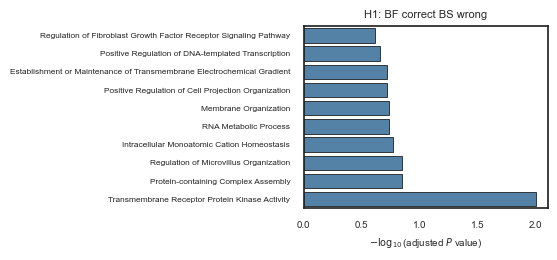

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_1308/1779832573.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


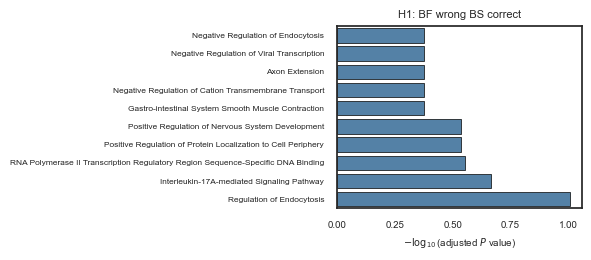

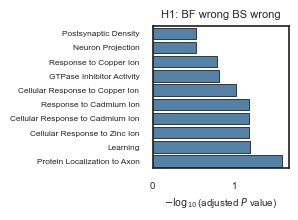

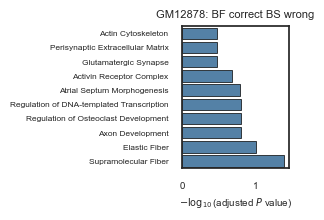

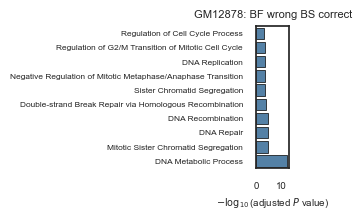

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_1308/1779832573.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


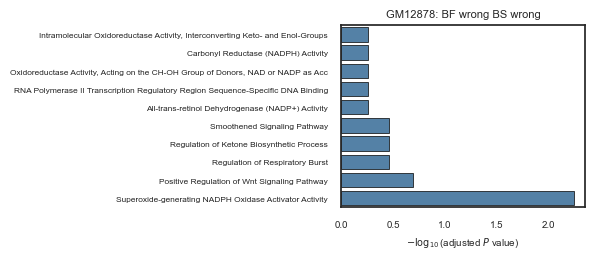

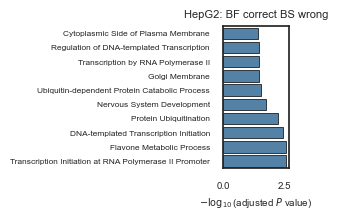

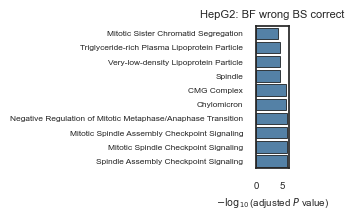

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_1308/1779832573.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


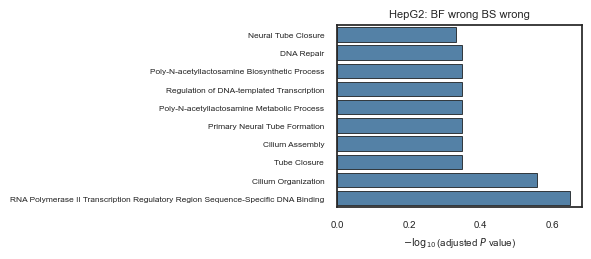

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

PLOT_DIR = OUT_DIR / "figures"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plot_df = top_go.copy()

plot_df["minus_log10_fdr"] = -np.log10(
    plot_df["Adjusted P-value"].replace(0, 1e-300)
)

plot_df["Term_short"] = (
    plot_df["Term"]
    .astype(str)
    .str.replace(r"\s*\(GO:\d+\)", "", regex=True)
)

# Optional: keep terms readable
plot_df["Term_short"] = plot_df["Term_short"].str.slice(0, 80)

for cell_type in ["H1", "GM12878", "HepG2"]:
    for group in group_order:
        sub = plot_df[
            (plot_df["cell_type"] == cell_type)
            & (plot_df["gene_set_name"] == group)
        ].copy()

        if sub.empty:
            print(f"No significant GO terms for {cell_type} {group}")
            continue

        sub = sub.sort_values("minus_log10_fdr", ascending=True)

        plt.figure(figsize=(8 / 2.54, 6 / 2.54))

        sns.barplot(
            data=sub,
            x="minus_log10_fdr",
            y="Term_short",
            color="steelblue",
            linewidth=0.5,
            edgecolor="black",
        )

        plt.xlabel(r"$-\log_{10}$(adjusted $P$ value)", fontsize=7)
        plt.ylabel("")
        plt.title(
            f"{cell_type}: {group.replace('_', ' ')}",
            fontsize=8,
        )

        plt.xticks(fontsize=7)
        plt.yticks(fontsize=6)
        plt.tight_layout()

        # save_name = f"{cell_type}_{group}_GO_barplot.pdf"
        # plt.savefig(PLOT_DIR / save_name, bbox_inches="tight")
        plt.show()

/Users/wanghan/miniconda3/envs/deepburst/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)


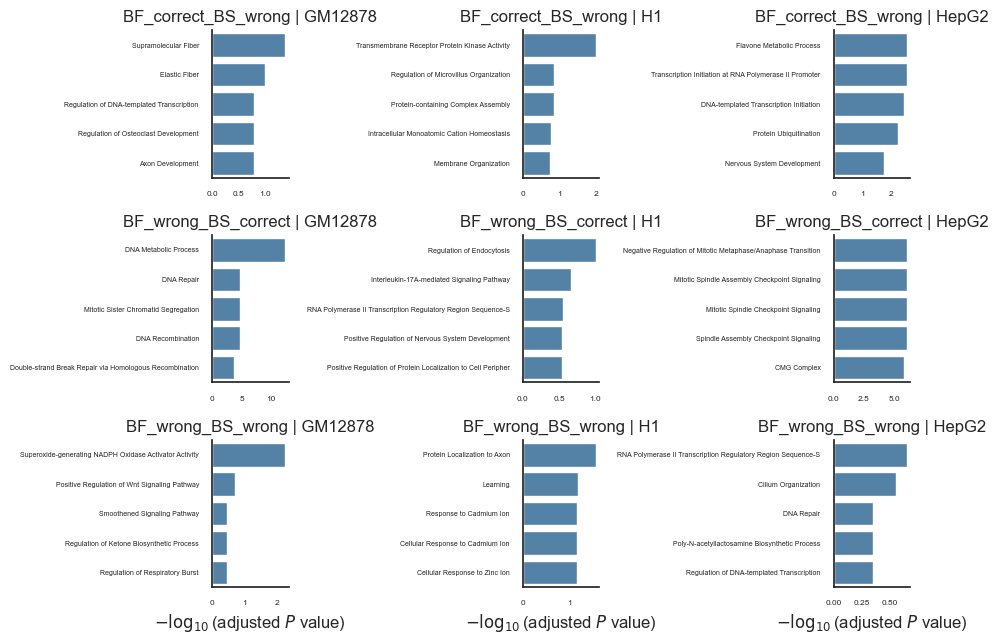

In [136]:
overview_df = (
    all_go
    .sort_values(["cell_type", "gene_set_name", "Adjusted P-value"])
    .groupby(["cell_type", "gene_set_name"], observed=False)
    .head(5)
    .copy()
)

overview_df["minus_log10_fdr"] = -np.log10(
    overview_df["Adjusted P-value"].replace(0, 1e-300)
)

overview_df["Term_short"] = (
    overview_df["Term"]
    .astype(str)
    .str.replace(r"\s*\(GO:\d+\)", "", regex=True)
    .str.slice(0, 60)
)

overview_df["panel"] = (
    overview_df["cell_type"].astype(str)
    + " | "
    + overview_df["gene_set_name"].astype(str).str.replace("_", " ")
)

g = sns.catplot(
    data=overview_df,
    x="minus_log10_fdr",
    y="Term_short",
    col="cell_type",
    row="gene_set_name",
    kind="bar",
    sharex=False,
    sharey=False,
    height=2.2,
    aspect=1.4,
    color="steelblue",
)

g.set_axis_labels(r"$-\log_{10}$(adjusted $P$ value)", "")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", labelsize=6)
    ax.tick_params(axis="y", labelsize=5)

plt.tight_layout()

# plt.savefig(
#     PLOT_DIR / "overview_top5_GO_terms_three_celltypes_error_groups.pdf",
#     bbox_inches="tight",
# )

plt.show()